#Assignment 1
#Syndel Huerta
A pilot survey was conducted of 30 individuals to understand their different attitudes towards discount stores
(e.g., K-Mart), which usually come with low levels of service versus departmental stores (e.g., Macys) which
come with higher levels of service. Respondents were asked their opinion on a 0-9 agree-disagree scale (where
0 indicates strongly disagree and 9 indicates strongly agree) on the following questions.
1. I never go back to a store that had treated me with disrespect.
2. I find salespeople who fawn over me irritating, I just expect them to courteous.
3. I have a lot of questions when I shop, I greatly appreciate a salesperson who is willing to spend time
answering my questions.
4. I care little for the fancy displays in departmental stores.
5. Discount stores are much more of a bargain than departmental stores.
The data for this study are provided in assg1.csv Using this data, answer the following questions.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# loading the dataset
df = pd.read_csv('assg1.csv')

# dropping the Resp column since it's just an ID
data = df.drop('Resp', axis=1)
print(data.head())

# scaling the data so variables are comparable
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# putting it back into a dataframe to look at it
df_scaled = pd.DataFrame(data_scaled, columns=data.columns)

# checking the stats to make sure scaling worked
print(df_scaled.describe().round(2))

   X1  X2  X3  X4  X5
0   6   0   8   4   4
1   4   9   2   8   9
2   2   8   2   6   9
3   5   7   3   9   6
4   3   8   3   9   6
          X1     X2     X3     X4     X5
count  30.00  30.00  30.00  30.00  30.00
mean   -0.00  -0.00   0.00  -0.00   0.00
std     1.02   1.02   1.02   1.02   1.02
min    -1.52  -1.71  -1.36  -1.89  -1.62
25%    -0.83  -0.88  -0.62  -1.01  -0.90
50%     0.21   0.29  -0.25   0.21  -0.19
75%     0.90   0.87   0.77   0.91   0.52
max     1.59   1.29   1.98   1.26   1.59


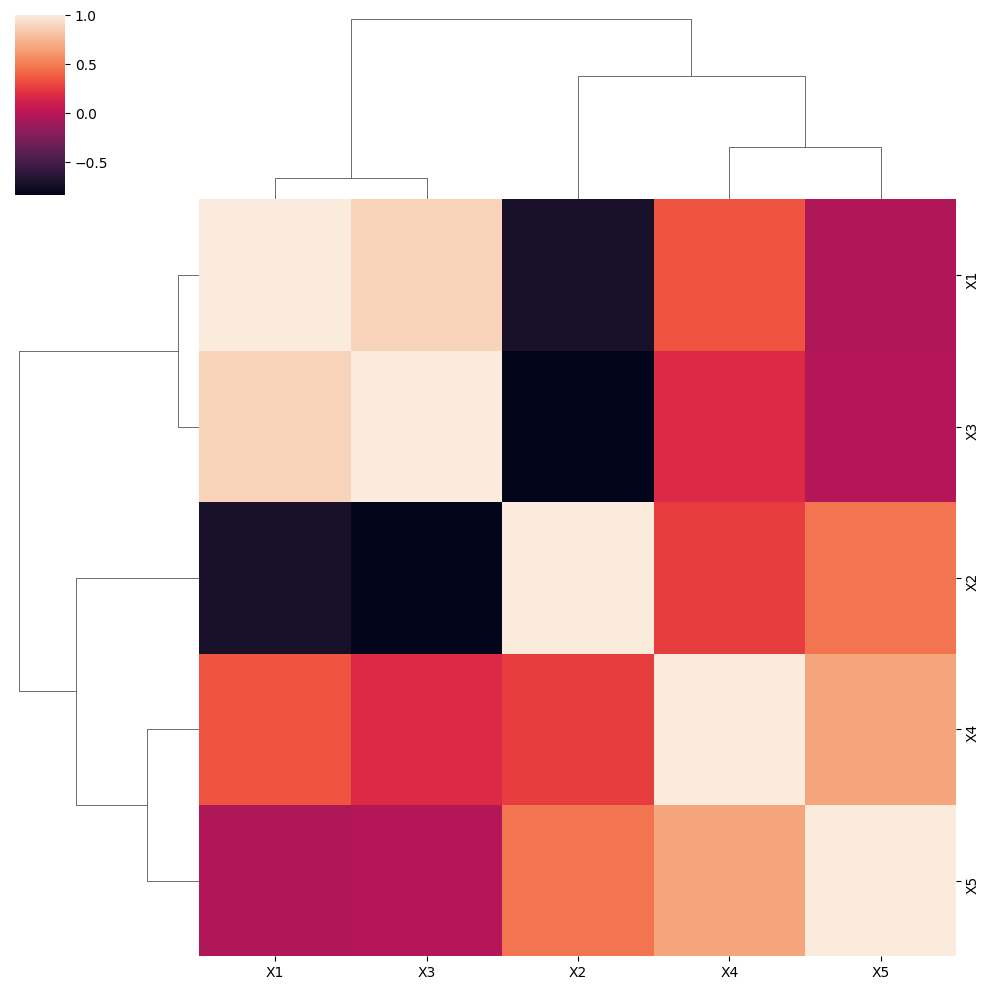

In [2]:
#Present the matrix of correlations for the five variables (X1-X5) and plot the correlations
#(using “sns.clustermap” function). Explain (in words) your inferences based on this exploratory analysis. (1 point)
sns.clustermap(df_scaled.corr())

X1 and X3 are very highly and positively correlated. The combination of the variables suggests that we have a group of people as customers that give a lot of importance to how they are treated when in the store.
Additionallly, X4 and X5 also show a high degree of positive correlation. This points to another customer segment that prioritizes getting value offers over their store experience. On the other hand, it is also worthwhile to keep in mind that x2 seems to have a slight negative correlation with x1 and x3, people that appreciate customer service will not mind the attentive attitude from fawning over them.

In [3]:
#Perform PCA on the data and show the results
#(including the summary of the PCA and the matrix showing the relationship between the factors and original attributes).
#Hint: Use the function “get_pca_summary” we defined in the in-class assignment for the summary of the PCA. (1 point)

# defining the function:
def get_pca_summary(pca, data_scaled):
    # getting the raw variance (eigenvalues) for the rule of thumb
    eigenvalues = pca.explained_variance_

    # getting the variance ratio (percentage)
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    # creating the summary table
    pca_summary = pd.DataFrame({
        'Component': [f'PC{i+1}' for i in range(len(eigenvalues))],
        'Eigenvalues (Variance)': eigenvalues,
        'Explained Variance Ratio': explained_variance_ratio,
        'Cumulative Variance': cumulative_variance
    })
    return pca_summary

# running pca with all 5 components first
pca = PCA(n_components=5)
pca_data = pca.fit_transform(data_scaled)

# getting the summary using the function
summary = get_pca_summary(pca, data_scaled)
print("PCA Summary:")
print(summary.round(3))

# looking at the relationship matrix (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(5)],
                        index=data.columns)
print("\nPCA Loadings:")
print(loadings.round(3))

PCA Summary:
  Component  Eigenvalues (Variance)  Explained Variance Ratio  \
0       PC1                   2.764                     0.534   
1       PC2                   1.916                     0.370   
2       PC3                   0.354                     0.068   
3       PC4                   0.097                     0.019   
4       PC5                   0.042                     0.008   

   Cumulative Variance  
0                0.534  
1                0.905  
2                0.973  
3                0.992  
4                1.000  

PCA Loadings:
      PC1    PC2    PC3    PC4    PC5
X1  0.555  0.232 -0.280  0.723 -0.191
X2 -0.571  0.212 -0.183  0.462  0.618
X3  0.580  0.157  0.311 -0.187  0.713
X4  0.017  0.686 -0.561 -0.461 -0.041
X5 -0.174  0.637  0.691  0.125 -0.267


In [4]:
#Write down the five equations that formally define relationship between the original attributes and the factors from the PCA. (1 point)
#PC1=0.555X1-0.571X2+0.58X3+0.017X4-0.174X5
#PC2=0.232X1+0.212X2+0.157X3+0.686X4+0.637X5
#PC3=-0.28X1-0.183X2+0.311X3-0.561X4+0.691X5
#PC4=0.723X1+0.462X2-0.187X3-0.461X4+0.125X5
#PC5=-0.191X1+0.618X2+0.713X3-0.041X4-0.267X5

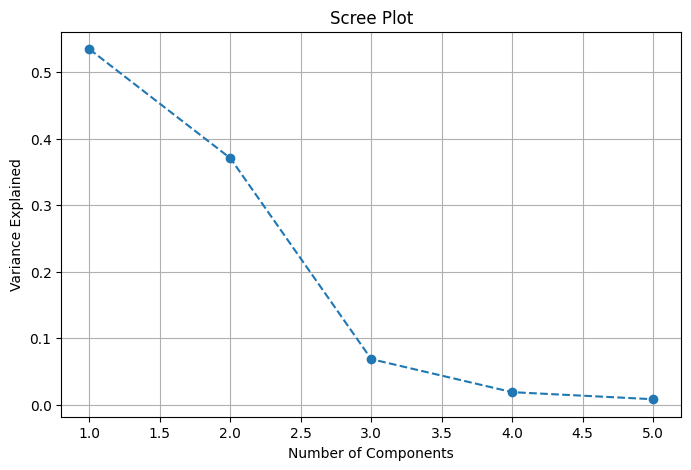

In [5]:
#How many factors or principal components should we retain? Explain your decision. (1.5 points)
# plotting the scree plot to decide how many to keep
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

I have decided to retain 2 components. Between these two, showing a cumulative variance of 0.9, we can explain the great majority of the data.

In [6]:
#6.Can you think of intuitive names for the first and second factors? What do these factors represent?
#Explain how you arrived at them. Hint: Use the equations that quantify the relationship between the
#original attributes and the factors from the PCA (from answer to Question 4) and focus on strong correlations. (2 points)

"Service Oriented": PC1 has high weights for x1 and x3, which we had signaled as customer service indicators.

"Purchase-focused": PC2 is more or less balanced but with stronger weights on x4 and x5. This group seems to care less about the attitude of people in the store or displays and more just focused on getting a good bargain or just buying what they need.

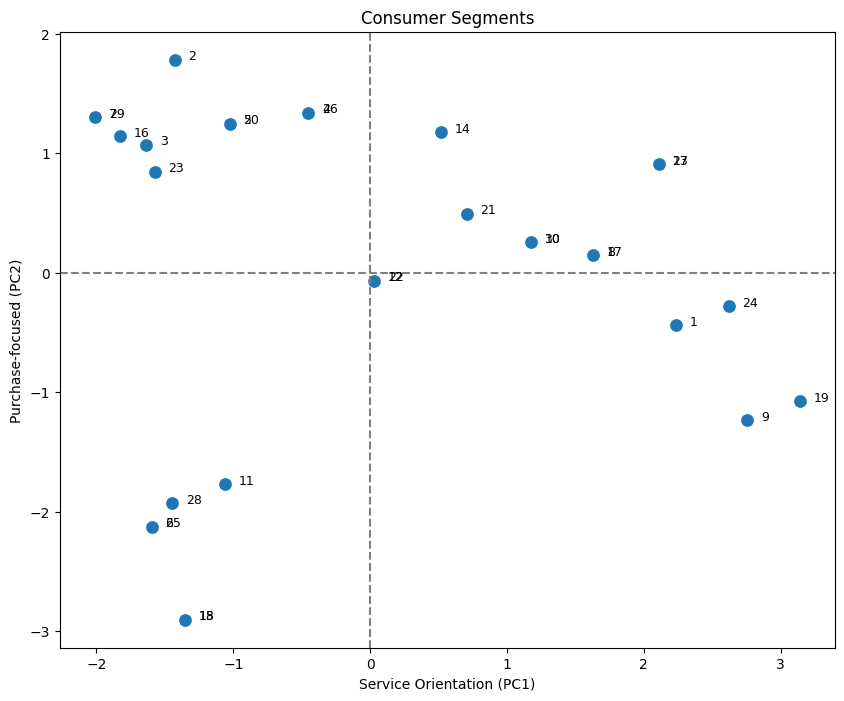

In [7]:
#7. Now plot all the consumers on a two-dimensional map based on the first two principal components.
#Label the x and y-axis using the names from your answer to the previous question. (1.5 points)
# grabbing the first two components for the plot
pca_df = pd.DataFrame(data=pca_data[:, :2], columns=['PC1', 'PC2'])

# plotting the customers on the map
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, s=100)

# labeling the axes with my names
plt.xlabel('Service Orientation (PC1)')
plt.ylabel('Purchase-focused (PC2)')
plt.title('Consumer Segments')

# adding respondent numbers so i can see who is who
for i in range(pca_df.shape[0]):
    plt.text(pca_df.PC1[i]+0.1, pca_df.PC2[i], str(df['Resp'][i]), fontsize=9)

# adding center lines
plt.axvline(0, color='grey', linestyle='--')
plt.axhline(0, color='grey', linestyle='--')

plt.show()

In [8]:
#8. Based on the plot from the previous answer, how many segments (roughly) do you find in the market?
#Hint: A segment is a group of consumers who are similar to each other in their tastes and preferences.(2 points)

I see roughly 3 segments on the chart.

In [9]:
#9. Describe the characteristics of each segment. Discuss the relationship between the segment characteristics and the original attributes? (2 points)

Group 1:One group that is not service-oriented and looks for bargains

Group 2: One that has a high proference for good customer service

Group 3: one that may be very hard to please because they do not focus on customer service or bargains, they are probably looking for an ideal experience.

In [10]:
#10. Which segment do you expect to be the most profitable and why?
#Assuming the data to be representative, what is the size of this segment (in percentage)? (2 points)

# counting how big this segment is
# assuming service seekers are those with PC1 > 0.5 (looking at the plot)
service_segment_count = pca_df[pca_df['PC1'] > 0.5].shape[0]
total_people = 30

print(f"Size of profitable segment: {service_segment_count/total_people * 100}%")

Size of profitable segment: 40.0%
